In [173]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from scipy.stats import pointbiserialr

ai = pd.read_csv('C:/Users/regin/Documents/Neuorientierung/Praktische Projekte Visual Studio/DataCamp Certification Churn/data/da_fitly_account_info.csv')
cs = pd.read_csv('C:/Users/regin/Documents/Neuorientierung/Praktische Projekte Visual Studio/DataCamp Certification Churn/data/da_fitly_customer_support.csv')
ua = pd.read_csv('C:/Users/regin/Documents/Neuorientierung/Praktische Projekte Visual Studio/DataCamp Certification Churn/data/da_fitly_user_activity.csv')


In [174]:
ai.info()
cs.info()
ua.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customer_id      400 non-null    str  
 1   email            400 non-null    str  
 2   state            400 non-null    str  
 3   plan             400 non-null    str  
 4   plan_list_price  400 non-null    int64
 5   churn_status     114 non-null    str  
dtypes: int64(1), str(5)
memory usage: 18.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    str    
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    str    
 3   topic                  918 non-null    str    
 4   resolution_time_hours  918 non-null    float64
 5   state                  918 non-null    int64  

# Analysis of Churn at Fit.ly Tech

## Business Problem
At Fit.ly Tech, increasing customer churn is recognized in the last two quarters. Since the costs of acquiring new customers are rising, is it crucial to hold existing customers to generate stable income. 
The following data analysis had the aim to identify patterns of churn using data of general account information, customer support tickets and user activity data. Each dataset comes from a different department of the company and is not standardized.

## Data validation and cleaning
To make sure to use validated and cleaned data sets, the following steps were done before exploratory analysis.

### Account information
The table contains 400 rows and 6 columns. No duplicates were found.
- customer_id: 400 unique values representing one customer/user per row. As in the other tables the term "user_id" is used, the following text it is focused on the term "user" only. The column "customer_id" is changed from form "C00000" to "00000" to make sure joining with the other tables is possible. Dtype object, no missing values.
- email: 400 unique values representing email address of user. Dtype object, no missing values.
- state: 50 unique values representing states of US (plausible values). Dtype object, no missing values.
- plan: 4 unique values representing the billing plan of the user account (plausible values), Dtype object, no missing values.
- plan_list_price: 106 unique values. Range from 0 to 148 (plausible values). No outliers detected (using 1.5*IQR method). Dtype float, no missing values.
- churn_status: 1 unique value "Y" representing accounts which are churned. 114 rows contains "Y", 286 rows have missing values (null). "Y" was replaced with "Yes", null was replaced with "No". Dtype object.
- signup_date: a column mentioned by the product manager but not found in this table. 

In [175]:
print(ai.shape)
print(ai.info())
print(ai.nunique())
print(ai.duplicated().sum())

ai['customer_id'] = ai['customer_id'].replace('C', '', regex=True)

print(ai['plan_list_price'].describe())

prices = ai['plan_list_price']
Q1 = prices.quantile(0.25)
Q3 = prices.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ai[(prices < lower_bound) | (prices > upper_bound)]
print(outliers)

ai['churn_status'] = ai['churn_status'].replace({'Y': 'Yes'}).fillna('No')
print(ai.head())

ai_merged['plan'] = pd.Categorical(
    ai_merged['plan'],
    categories=['Free', 'Basic', 'Pro', 'Enterprise'],
    ordered=True
)

(400, 6)
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customer_id      400 non-null    str  
 1   email            400 non-null    str  
 2   state            400 non-null    str  
 3   plan             400 non-null    str  
 4   plan_list_price  400 non-null    int64
 5   churn_status     114 non-null    str  
dtypes: int64(1), str(5)
memory usage: 18.9 KB
None
customer_id        400
email              400
state               50
plan                 4
plan_list_price    106
churn_status         1
dtype: int64
0
count    400.000000
mean      43.965000
std       45.263348
min        0.000000
25%        0.000000
50%       26.000000
75%       77.250000
max      148.000000
Name: plan_list_price, dtype: float64
Empty DataFrame
Columns: [customer_id, email, state, plan, plan_list_price, churn_status]
Index: []
  customer_id                  email       

### Customer support
The table contains 918 rows and 7 columns. No duplicates were found. 
- ticket_time: 918 unique values representing the time (Pacific time) the user request was made. Dtype was changed from object to datetime, no missing values. 
- user_id: 367 unique values representing the user who made the request. Dtype was changed from int to object. No missing values.
- channel: 4 unique values representing the channel request was made in (plausible values). Value "-" is likely a missing value but due to no information how to replace it, it remained unchanged. Dtype object, no missing values.
- topic: 4 unique values representing the topic of the ticket (plausible values), dtype object, no missing values.
- resolution_time_hours: 918 unique values representing how long it takes to solve the ticket. Calculated beforehand in ETL from start time and end time of the ticket. dtype float, no missing values.
- state: 2 unique values (0, 1), as no relation to either the state column in the table account information nor the information from the department was found, the column was excluded from analysis. Dtype int, no missing values.
- comments: 46 unique values representing optional user comments in the request. All comments refer to GDPR issues and are used to filter the data for analysis which is explained later in the report. Dtype object, no missing values.


In [176]:
print(cs.shape)
print(cs.info())
print(cs.nunique())
print(cs.duplicated().sum())

cs['ticket_time'] = pd.to_datetime(cs['ticket_time'])
cs['user_id'] = cs['user_id'].astype(str)

cs['channel'].value_counts()
cs['topic'].value_counts()

#print(ai['plan_list_price'].describe())

(918, 7)
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    str    
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    str    
 3   topic                  918 non-null    str    
 4   resolution_time_hours  918 non-null    float64
 5   state                  918 non-null    int64  
 6   comments               46 non-null     str    
dtypes: float64(1), int64(2), str(4)
memory usage: 50.3 KB
None
ticket_time              918
user_id                  367
channel                    4
topic                      4
resolution_time_hours    735
state                      2
comments                  19
dtype: int64
0


topic
billing      239
other        228
technical    226
account      225
Name: count, dtype: int64

In [218]:
prices = cs['resolution_time_hours']
Q1 = prices.quantile(0.25)
Q1
Q3 = prices.quantile(0.75)
Q3
IQR = Q3 - Q1
IQR
lower_bound = Q1 - 2 * IQR
lower_bound
upper_bound = Q3 + 2 * IQR
upper_bound
outliers = cs[(prices < lower_bound) | (prices > upper_bound)]['resolution_time_hours']
print(outliers)
print(outliers.count())

17     28.24
150    28.18
177    29.35
192    28.94
195    31.73
232    28.58
245    27.51
280    28.05
396    28.27
397    29.15
481    28.15
561    27.81
586    29.20
625    28.84
689    29.21
726    31.54
744    28.20
776    28.57
784    28.06
886    28.66
913    32.46
Name: resolution_time_hours, dtype: float64
21


### User activity

The table contains 445 rows and 3 columns. No duplicates were found. 
- event_time: 445 unique values representing the time of the user activity. Dtype was changed from object to datetime, no missing values.
- user_id: 246 unique values representing the user who made the activity. Dtype was changed from int to object. No missing values.
- event_type: 4 unique values representing the type of activity (plausible values). Dtype object, no missing values.

In [178]:
print(ua.shape)
print(ua.info())
print(ua.nunique())
print(ua.duplicated().sum())

ua['event_time'] = pd.to_datetime(ua['event_time'])
ua['user_id'] = ua['user_id'].astype(str)

ua['event_type'].value_counts()

(445, 3)
<class 'pandas.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   event_time  445 non-null    str  
 1   user_id     445 non-null    int64
 2   event_type  445 non-null    str  
dtypes: int64(1), str(2)
memory usage: 10.6 KB
None
event_time    445
user_id       246
event_type      4
dtype: int64
0


event_type
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: count, dtype: int64

## GDPR cleaning

Due to GDPR only data can be used for analysis where users do not contradict to use their information. In the customer support dataset some information about GDPR was found in the column "comments". As a result, in all three datasets the rows containing information about these unique users who made comments were deleted. 

In [179]:
users_to_del = cs[cs['comments'].notnull()]
users_to_del = users_to_del['user_id'].unique()
len(users_to_del)

ai = ai[~ai['customer_id'].isin(users_to_del)]
len(ai)
cs = cs[~cs['user_id'].isin(users_to_del)]
len(cs)
ua = ua[~ua['user_id'].isin(users_to_del)]
len(ua)

401

## Exploratory analysis

With the GDPR cleaning, the datasets contain the following lengths:
- account information: 357 rows/users
- customer support: 781 rows
- user activity: 401 rows

### Joining datasets
To join the account information with customer support, the customer support table was grouped by user_id and aggregated by count of tickets and median resolution time.
To join the user activity information, the user activity table was grouped by user_id and aggregated by count of events.

In [180]:
cs_grouped = cs.groupby('user_id').agg({'ticket_time': 'count', \
                                        'resolution_time_hours': 'median'}).reset_index()

ua_grouped = ua.groupby('user_id').agg({'event_time': 'count'}).reset_index()

ai_merged = ai.merge(cs_grouped, how='left', left_on='customer_id', right_on='user_id')
ai_merged = ai_merged.merge(ua_grouped, how='left', left_on='customer_id', right_on='user_id')
ai_merged = ai_merged[['customer_id', 'state', 'plan', 'plan_list_price', 'churn_status', 'ticket_time', \
                       'resolution_time_hours', 'event_time']]
ai_merged.rename(columns={'ticket_time': 'num_tickets', 'event_time': 'num_events'}, inplace=True)
ai_merged['num_tickets'] = ai_merged['num_tickets'].fillna(0)
#ai_merged['resolution_time_hours'] = ai_merged['resolution_time_hours'].fillna(0)
ai_merged['num_events'] = ai_merged['num_events'].fillna(0)
ai_merged

,customer_id,state,plan,plan_list_price,churn_status,num_tickets,resolution_time_hours,num_events
0,10000,New Jersey,Enterprise,105,Yes,3.0,22.400,3.0
1,10001,Louisiana,Basic,22,Yes,4.0,16.645,1.0
2,10002,Oklahoma,Basic,24,No,3.0,7.370,1.0
3,10003,Michigan,Free,0,No,1.0,2.190,1.0
4,10004,Texas,Enterprise,119,No,4.0,8.410,4.0
...,...,...,...,...,...,...,...,...
352,10395,Arizona,Free,0,No,3.0,5.280,2.0
353,10396,Vermont,Free,0,No,0.0,NaN,2.0
354,10397,Vermont,Free,0,Yes,5.0,18.680,0.0
355,10398,Alabama,Enterprise,81,No,2.0,3.635,0.0


### Exploration of Individual Variables

To get an overview about the given variables, single variable plots were conducted.

In the plot below it can be seen that 260 users are still active while 97 users already churned. The resulting churn rate is 27.1%. 

Looking at plan types it can be seen that the free plan is used 94 times, while 263 users have a paid plan. The paid plans range from 10$ to 148$, with a mean of 61$ (calculated for only paid plans).

For users who opened support tickets, the median resolution time is approximately 7 hours and the mean is around 9 hours.
Resolution times range from 1 hour to 32 hours, showing that some tickets took significantly longer to resolve.

Among users who created support tickets, the number of tickets ranges from 1 to 5.
Among users who generated activity events, the number of events ranges from 1 to 6.


Text(0.5, 1.0, 'Number of Users who churned or not churned their accounts')

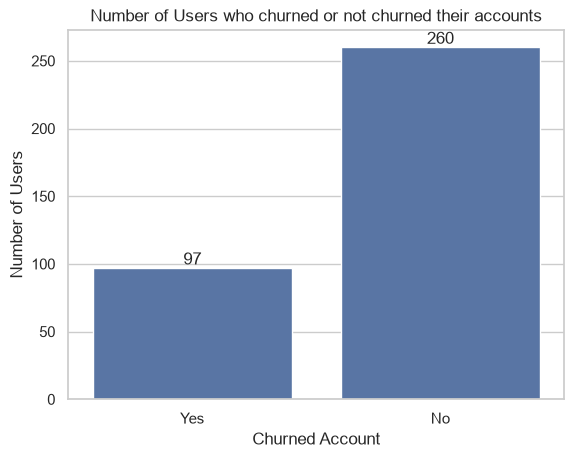

In [181]:
ax = sns.countplot(x=ai_merged['churn_status'])
ax.bar_label(ax.containers[0])
plt.xlabel('Churned Account')
plt.ylabel('Number of Users')
plt.title('Number of Users who churned or not churned their accounts')

263

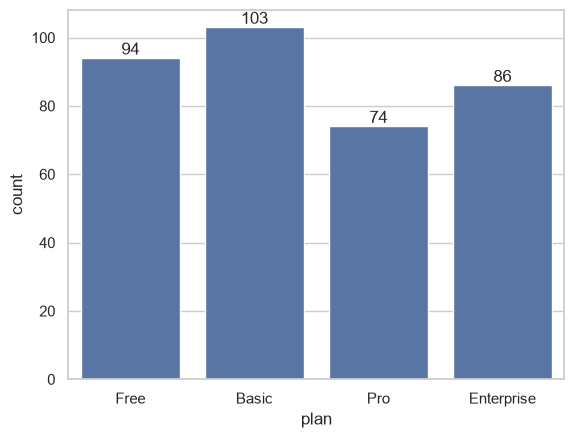

In [182]:
ax = sns.countplot(x=ai_merged['plan'], order=['Free', 'Basic', 'Pro', 'Enterprise'])
ax.bar_label(ax.containers[0])
357-94

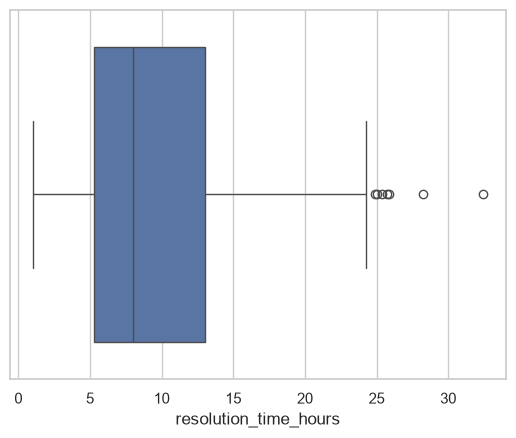

count    324.000000
mean       9.953333
std        6.357357
min        0.990000
25%        5.287500
50%        8.030000
75%       13.030000
max       32.460000
Name: resolution_time_hours, dtype: float64

In [183]:
ax2 = sns.boxplot(x = ai_merged['resolution_time_hours'])
plt.show()

ai_merged['resolution_time_hours'].describe()
#ai_merged['resolution_time_hours'].median()

count    263.000000
mean      61.441065
std       43.490230
min       10.000000
25%       23.000000
50%       49.000000
75%       95.000000
max      148.000000
Name: plan_list_price, dtype: float64

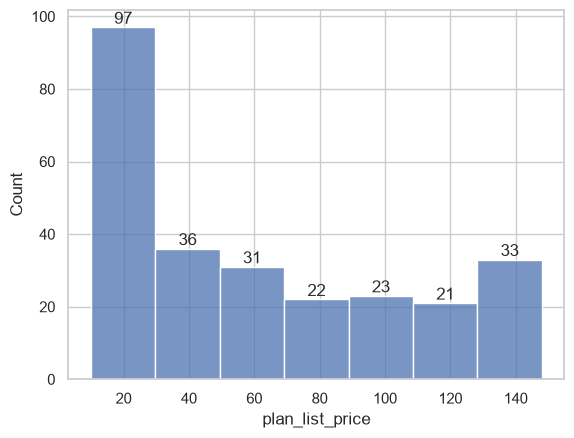

In [184]:
plp_g0 = ai_merged[ai_merged['plan_list_price'] > 0]['plan_list_price']
ax = sns.histplot(plp_g0, bins=7)
ax.bar_label(ax.containers[0])
plp_g0.describe()

<Axes: xlabel='num_tickets', ylabel='Count'>

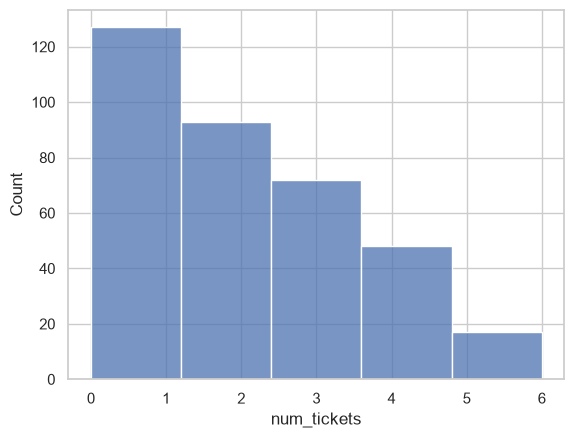

In [185]:
sns.histplot(ai_merged['num_tickets'], bins=5)

<Axes: xlabel='num_events', ylabel='Count'>

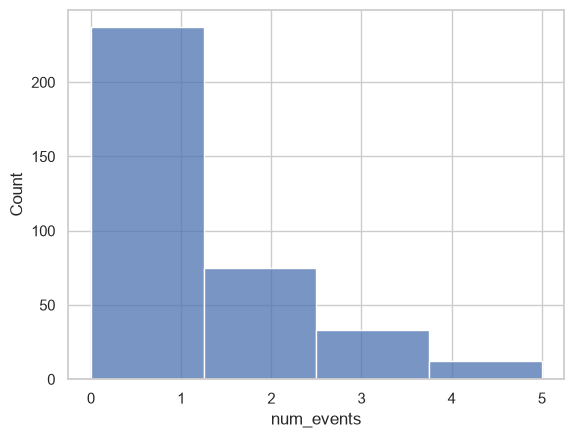

In [186]:
sns.histplot(ai_merged['num_events'], bins=4)

<Axes: xlabel='channel', ylabel='count'>

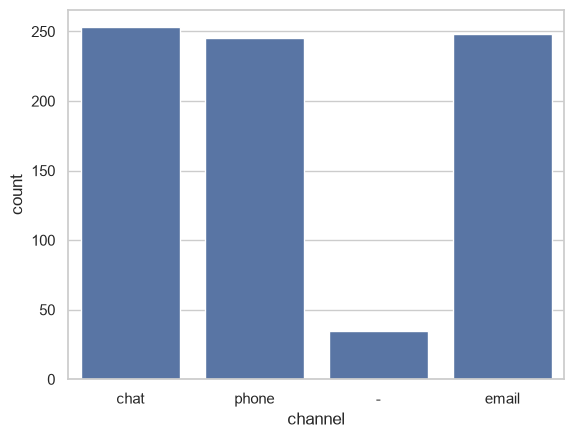

In [187]:
sns.countplot(x=cs['channel'])

<Axes: xlabel='topic', ylabel='count'>

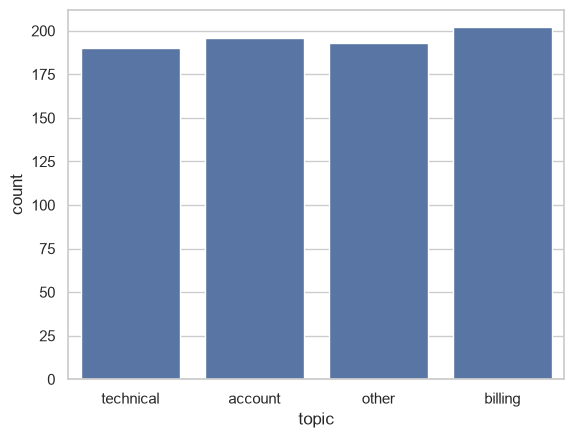

In [188]:
sns.countplot(x=cs['topic'])

<Axes: xlabel='event_type', ylabel='count'>

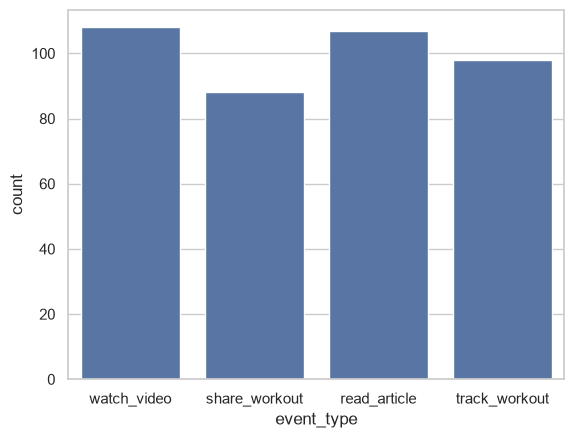

In [189]:
sns.countplot(x=ua['event_type'])

### ### Exploration of Multiple Variables

### Churn analysis
As the main subject of the data analysis is identifying the drivers of increasing churns, the variables were analysed differenciating between churned and non-churned accounts.
Looking at differences in plan type, it can be seen that 38% of users with the free plan churned, while 24% on basic, 19% on Pro and 26% on Enterprise plan churned. 
Looking at differences in channel of the ticket, it can be seen that most tickets associated with a churned account were made via chat, while it is less via email and phone. 
Customers associated with longer support-ticket resolution times had higher observed churn rates."

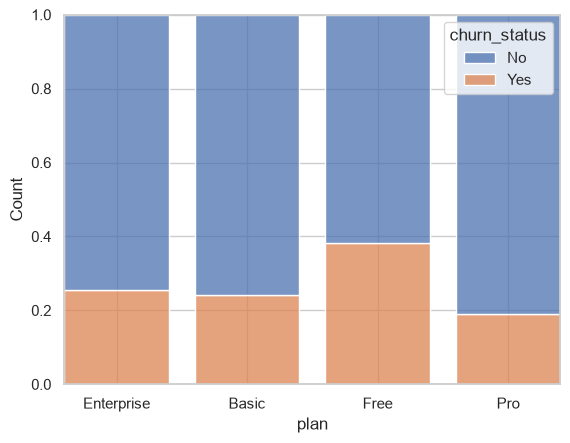

In [190]:
# ax = sns.countplot(x=ai_merged['plan'], hue=ai_merged['churn_status'], order = ['Free', 'Basic', 'Pro', 'Enterprise'])
# #ax.bar_label(ax.containers[0])

# plan_churn_status = ai_merged.groupby(['plan','churn_status'])['churn_status'].agg('count')

# plan_churn_rate = (
#     ai_merged
#     .groupby('plan')['churn_status']
#     .value_counts(normalize=True)
#     .rename('proportion')
#     .reset_index())

# plan_churn_status
# plan_churn_rate

ax = sns.histplot(
    data=ai_merged,
    x="plan",
    hue="churn_status",
    multiple="fill",
    discrete=True,
    shrink=0.8, 
    hue_order= ['No', 'Yes']
)

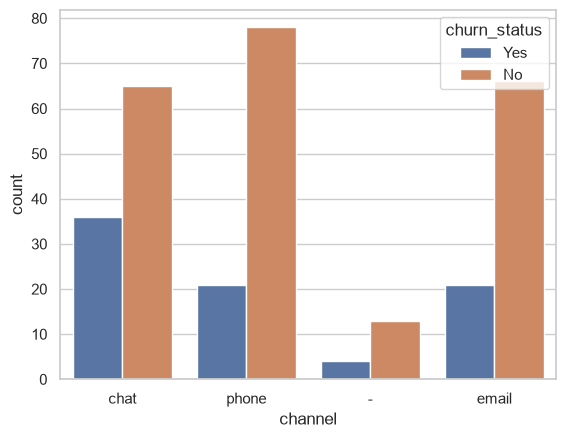

In [191]:
ax = sns.countplot(x=cs['channel'], hue=ai_merged['churn_status'])
#ax.bar_label(ax.containers[0])


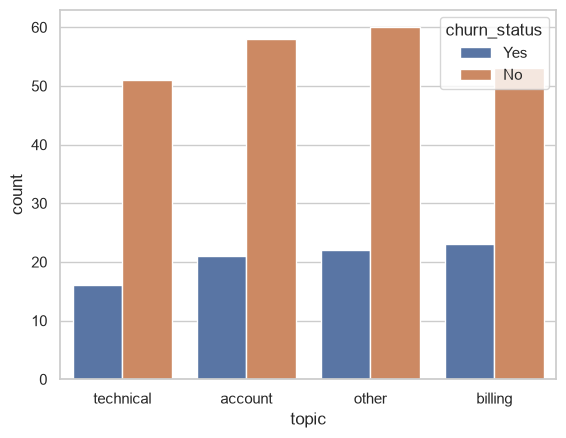

In [192]:
ax = sns.countplot(x=cs['topic'], hue=ai_merged['churn_status'])
#ax.bar_label(ax.containers[0])

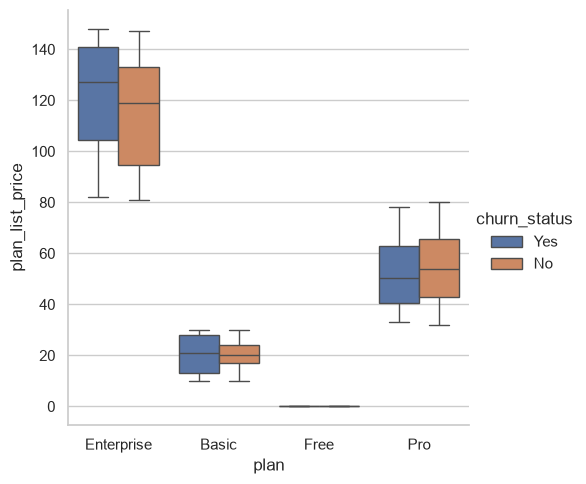

In [193]:
sns.catplot(data=ai_merged, x='plan', y='plan_list_price', kind='box',hue='churn_status')

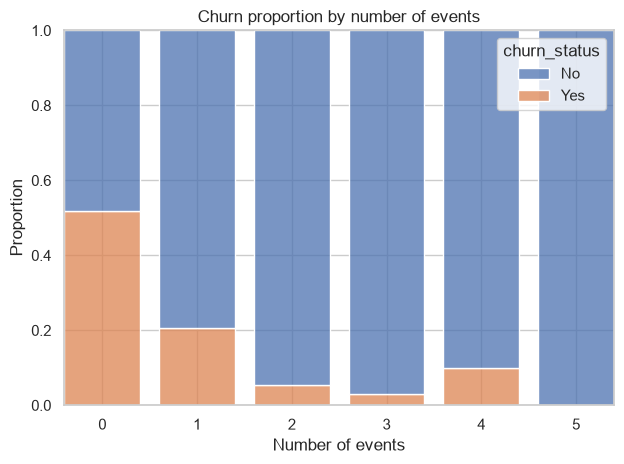

In [194]:
ax = sns.histplot(
    data=ai_merged,
    x="num_events",
    hue="churn_status",
    multiple="fill",
    discrete=True,
    shrink=0.8,
    hue_order=['No','Yes']
)


ax.set_xlabel("Number of events")
ax.set_ylabel("Proportion")
ax.set_title("Churn proportion by number of events")

#plt.legend(title="Churn")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of users')

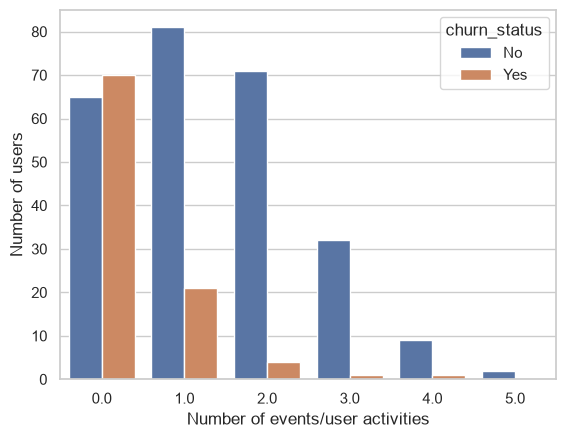

In [195]:
ax = sns.countplot(x=ai_merged['num_events'], hue=ai_merged['churn_status'])
plt.xlabel('Number of events/user activities')
plt.ylabel('Number of users')

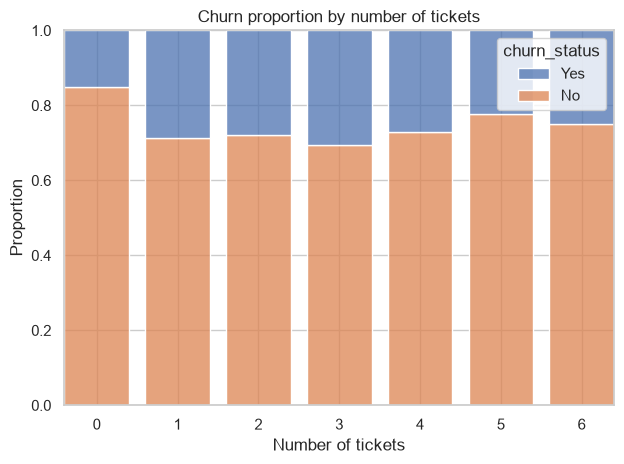

In [196]:
ax = sns.histplot(
    data=ai_merged,
    x="num_tickets",
    hue="churn_status",
    multiple="fill",
    discrete=True,
    shrink=0.8
)


ax.set_xlabel("Number of tickets")
ax.set_ylabel("Proportion")
ax.set_title("Churn proportion by number of tickets")

#plt.legend(title="Churn")
plt.tight_layout()
plt.show()

<Axes: xlabel='churn_status', ylabel='resolution_time_hours'>

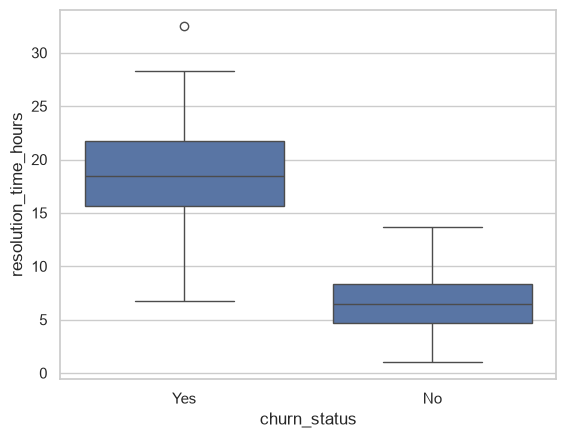

In [197]:
sns.boxplot(data=ai_merged, x='churn_status', y='resolution_time_hours')

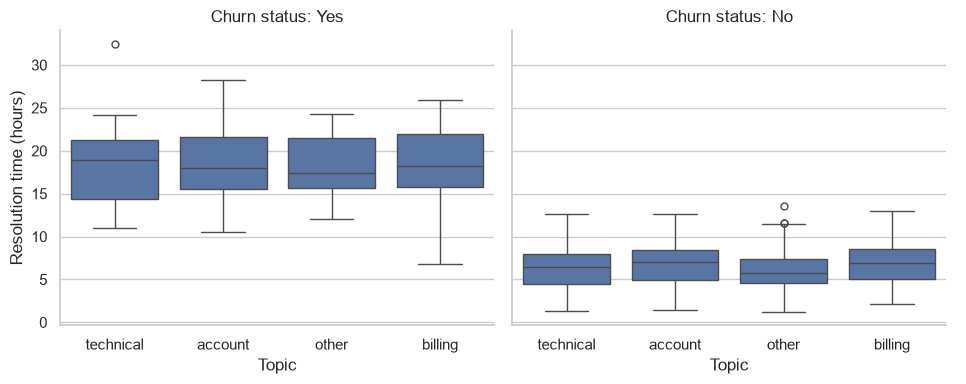

In [198]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    col=ai_merged["churn_status"],
    y=ai_merged["resolution_time_hours"],
    x=cs["topic"],
    kind="box",
    col_wrap=2,
    height=4,
    aspect=1.2
)

g.set_axis_labels("Topic", "Resolution time (hours)")
g.set_titles("Churn status: {col_name}")

plt.tight_layout()
plt.show()

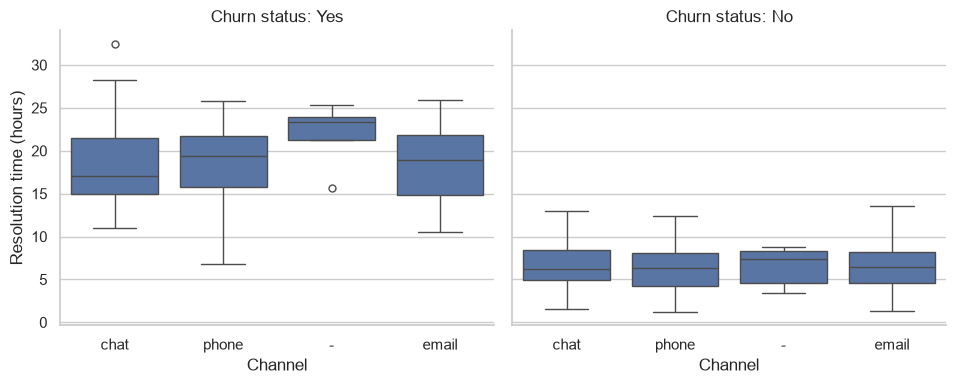

In [199]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    col=ai_merged["churn_status"],
    y=ai_merged["resolution_time_hours"],
    x=cs["channel"],
    kind="box",
    col_wrap=2,
    height=4,
    aspect=1.2
)

g.set_axis_labels("Channel", "Resolution time (hours)")
g.set_titles("Churn status: {col_name}")

plt.tight_layout()
plt.show()

In [200]:
ai_merged['churn'] = ai_merged['churn_status'].replace({'Yes': 1, 'No': 0}).astype(int)
r, p = pointbiserialr(
    ai_merged["churn"],
    ai_merged["resolution_time_hours"]
)

print(f"Correlation: {r:.3f}")
print(f"p-value: {p:.4f}")

Correlation: nan
p-value: nan


<Axes: xlabel='plan_list_price', ylabel='resolution_time_hours'>

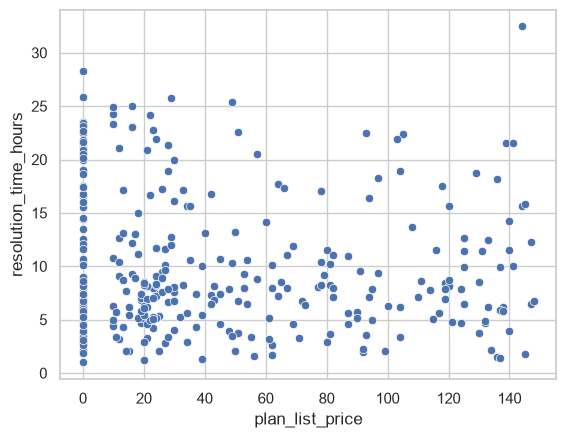

In [219]:
sns.scatterplot(x=ai_merged['plan_list_price'], y= ai_merged['resolution_time_hours'])